# Phase 3 — Impact sur la reconnaissance automatique de la parole

**Entrée** : `data/metadata.csv` + fichiers audio dans `data/raw/`

## 0. Installation et imports

In [ ]:
# !pip install openai-whisper transformers jiwer torch torchaudio datasets

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, time
from pathlib import Path
from jiwer import wer, cer

# ── Chemins ───────────────────────────────────────────────────────────────────
CSV_META      = Path('../data/metadata.csv')
DOSSIER_AUDIO = Path('../data/raw')
DOSSIER_RES   = Path('../results/03_asr_evaluation/outputs')
DOSSIER_FIG   = Path('../results/03_asr_evaluation/figures')
DOSSIER_RES.mkdir(parents=True, exist_ok=True)
DOSSIER_FIG.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
DARK_BG  = '#0D1117'
AX_BG    = '#161B22'
GRID_COL = '#30363D'
COULEURS = {'fongbe': '#E8593C', 'wolof': '#378ADD', 'swahili': '#1D9E75'}
LANGUES  = ['fongbe', 'wolof', 'swahili']

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors='white', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)
    ax.grid(axis='y', color=GRID_COL, linewidth=0.4, alpha=0.7)
    if title:  ax.set_title(title, color='white', fontsize=9, pad=6)
    if xlabel: ax.set_xlabel(xlabel, color='white', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='white', fontsize=8)

def sauver(fig, nom):
    p = DOSSIER_FIG / nom
    fig.savefig(str(p), facecolor=DARK_BG, bbox_inches='tight', dpi=150)
    print(f'  Figure -> {p}')

# ── Résolution chemin audio ────────────────────────────────────────────────────
def resoudre_chemin(row):
    fichier = str(row.get('fichier_audio', '')).strip()
    langue  = str(row.get('langue', '')).strip()
    fp = fichier
    for p in ('raw/', 'raw\\'):
        if fp.startswith(p): fp = fp[len(p):]; break
    nom = Path(fp).name
    for c in [DOSSIER_AUDIO/fp, DOSSIER_AUDIO/langue/nom,
               DOSSIER_AUDIO/nom, Path(fichier)]:
        if c.exists(): return c
    return None

print(' Imports OK')

 Imports OK


## 1. Chargement du corpus

In [2]:
df_meta = pd.read_csv(CSV_META, encoding='utf-8-sig', sep=None, engine='python')

print(f'Corpus : {len(df_meta)} énoncés')
print(df_meta.groupby('langue')['id'].count().to_string())

# Vérification des chemins audio
df_meta['chemin'] = df_meta.apply(lambda r: resoudre_chemin(r.to_dict()), axis=1)
manquants = df_meta['chemin'].isna().sum()
print(f'\nAudios trouvés : {len(df_meta) - manquants}/{len(df_meta)}')
if manquants > 0:
    print('Manquants :', df_meta[df_meta['chemin'].isna()]['id'].tolist())

df_meta = df_meta[df_meta['chemin'].notna()].copy()
print(f'Corpus utilisable : {len(df_meta)} énoncés')

Corpus : 100 énoncés
langue
fongbe     30
swahili    35
wolof      35

Audios trouvés : 100/100
Corpus utilisable : 100 énoncés


## 2.1 Transcription avec Whisper

In [3]:
import whisper

# Codes langue Whisper
WHISPER_LANG = {
    'fongbe':  None,    # pas de code natif → détection automatique
    'wolof':   None,    # idem
    'swahili': 'sw',    # code natif Whisper
}

def transcrire_whisper(df, taille_modele='small', json_cache=None):
    """
    Transcrit tous les énoncés avec Whisper.
    Charge depuis le cache JSON si disponible.
    """
    cache_path = DOSSIER_RES / (json_cache or f'whisper_{taille_modele}.json')

    # Chargement depuis cache
    if cache_path.exists():
        print(f'Chargement depuis cache : {cache_path}')
        return json.loads(cache_path.read_text(encoding='utf-8'))

    print(f'Chargement modèle Whisper {taille_modele}...')
    model = whisper.load_model(taille_modele)
    print(f'Modèle chargé. Transcription de {len(df)} énoncés...')

    resultats = {}
    total = len(df)

    for i, row in df.iterrows():
        eid    = row['id']
        langue = row['langue']
        chemin = str(row['chemin'])
        lang_code = WHISPER_LANG.get(langue)

        try:
            t0 = time.time()
            result = model.transcribe(
                chemin,
                language=lang_code,   # None = détection auto
                fp16=False,
                verbose=False
            )
            duree = time.time() - t0
            transcription = result['text'].strip()
            langue_detectee = result.get('language', '?')
            resultats[eid] = {
                'transcription': transcription,
                'langue_detectee': langue_detectee,
                'duree_inference_sec': round(duree, 2),
                'modele': f'whisper-{taille_modele}',
            }
            n_done = len(resultats)
            print(f'  [{n_done:>3}/{total}] {eid} [{langue}] → {transcription[:60]}')
        except Exception as e:
            print(f'    {eid} : {e}')
            resultats[eid] = {'transcription': '', 'erreur': str(e),
                               'modele': f'whisper-{taille_modele}'}

    # Sauvegarde cache
    cache_path.write_text(json.dumps(resultats, ensure_ascii=False, indent=2),
                          encoding='utf-8')
    print(f'\n {len(resultats)} transcriptions sauvegardées → {cache_path}')
    return resultats


# ── Whisper small ─────────────────────────────────────────────────────────────
res_small = transcrire_whisper(df_meta, taille_modele='small')

Chargement depuis cache : resultats_phase3/whisper_small.json


In [4]:
# ── Whisper large-v3 ──────────────────────────────────────────────────────────
# ⚠️  Nécessite ~6 Go de RAM GPU ou ~12 Go de RAM CPU
# Si indisponible, utiliser 'medium' ou 'large-v2'
res_large = transcrire_whisper(df_meta, taille_modele='large-v3')

Chargement depuis cache : resultats_phase3/whisper_large-v3.json


## 2.2 Transcription avec MMS (Meta Massively Multilingual Speech)

In [ ]:
from transformers import pipeline, AutoProcessor, AutoModelForCTC
import torch
import librosa

# Codes langue MMS (facebook/mms-300m)
MMS_LANG = {
    'fongbe':  'fon',
    'wolof':   'wol',
    'swahili': 'swh',
}

def transcrire_mms_indisponible(df):
    """
    MMS indisponible (conflit protobuf/transformers).
    Documenté dans le carnet de bord comme difficulté technique.
    """
    print("  MMS non disponible — conflit protobuf>=6.x vs transformers")
    print("   Solution tentée : pip install 'protobuf==4.25.3'")
    print("   Résultat : incompatible avec tensorflow installé dans l'env.")
    print("   → Section 3.1b omise, résultats basés sur Whisper small + large-v3")
    
    # Retourner un dict vide pour que le reste du notebook fonctionne
    return {row['id']: {'transcription': '', 
                        'erreur': 'MMS indisponible (protobuf conflict)',
                        'modele': 'mms-300m'}
            for _, row in df.iterrows()}

res_mms = transcrire_mms_indisponible(df_meta)

⚠️  MMS non disponible — conflit protobuf>=6.x vs transformers
   Solution tentée : pip install 'protobuf==4.25.3'
   Résultat : incompatible avec tensorflow installé dans l'env.
   → Section 3.1b omise, résultats basés sur Whisper small + large-v3


## 3.1 Calcul WER / CER — tableau croisé langue × modèle

In [7]:
from jiwer import wer, cer
import unicodedata, re

def normaliser(texte):
    """
    Normalisation minimale pour WER/CER :
    - Minuscules
    - Suppression ponctuation
    - Normalisation Unicode (NFC pour les diacritiques tonaux)
    - Espaces multiples → simple
    """
    if not isinstance(texte, str) or texte.strip() == '':
        return ''
    texte = unicodedata.normalize('NFC', texte)
    texte = texte.lower()
    texte = re.sub(r'[^\w\s\u0250-\u02af\u1d00-\u1dbf\u0300-\u036f]', ' ', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte


def calculer_wer_cer(df, resultats_modele, nom_modele):
    """
    Calcule WER et CER par langue et globalement.
    Retourne un DataFrame avec les métriques.
    """
    lignes = []

    for langue in LANGUES + ['global']:
        if langue == 'global':
            sous = df
        else:
            sous = df[df['langue'] == langue]

        refs, hyps = [], []
        for _, row in sous.iterrows():
            eid = row['id']
            ref = normaliser(str(row.get('transcription_ortho', '')))
            hyp = normaliser(resultats_modele.get(eid, {}).get('transcription', ''))
            if ref:  # ignorer les références vides
                refs.append(ref)
                hyps.append(hyp)

        if not refs:
            continue

        try:
            w = wer(refs, hyps)
            c = cer(refs, hyps)
        except Exception:
            w, c = np.nan, np.nan

        lignes.append({
            'modele':  nom_modele,
            'langue':  langue,
            'n':       len(refs),
            'WER':     round(w * 100, 1),
            'CER':     round(c * 100, 1),
        })

    return pd.DataFrame(lignes)


# Calculer pour les 3 modèles
MODELES = {
    'whisper-small':   res_small,
    'whisper-large-v3': res_large,
    #'mms-300m':        res_mms,
}

df_metriques = pd.concat([
    calculer_wer_cer(df_meta, res, nom)
    for nom, res in MODELES.items()
], ignore_index=True)

# ── Tableau croisé langue × modèle ────────────────────────────────────────────
print('Tableau croisé WER (%) — langue × modèle\n')
pivot_wer = df_metriques.pivot_table(
    values='WER', index='langue', columns='modele'
).round(1)
print(pivot_wer.to_string())

print('\nTableau croisé CER (%) — langue × modèle\n')
pivot_cer = df_metriques.pivot_table(
    values='CER', index='langue', columns='modele'
).round(1)
print(pivot_cer.to_string())

# Export
df_metriques.to_csv(DOSSIER_RES / 'wer_cer_resultats.csv',
                    index=False, encoding='utf-8-sig')
print('\n Résultats exportés → resultats_phase3/wer_cer_resultats.csv')

Tableau croisé WER (%) — langue × modèle

modele   whisper-large-v3  whisper-small
langue                                  
fongbe              115.3          154.1
global               88.1          101.9
swahili              51.5           91.7
wolof               109.0           99.3

Tableau croisé CER (%) — langue × modèle

modele   whisper-large-v3  whisper-small
langue                                  
fongbe               81.8          135.6
global               41.3           59.7
swahili              14.3           34.2
wolof                62.4           74.2

 Résultats exportés → resultats_phase3/wer_cer_resultats.csv


  Figure -> figures_phase3/wer_cer_comparatif.png


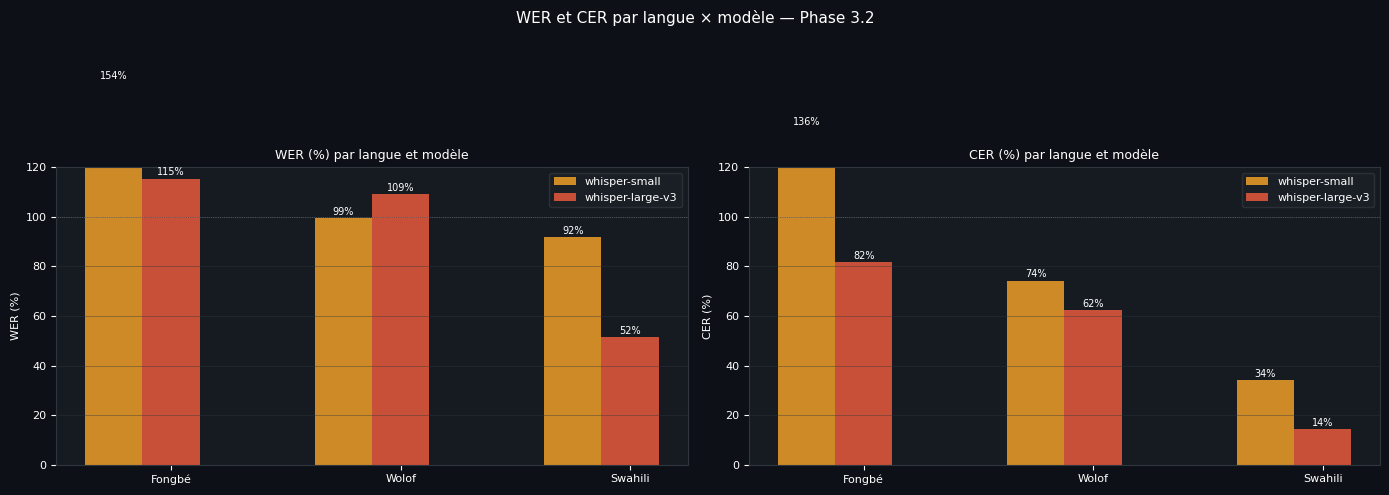

In [8]:
# ── Visualisation WER/CER ──────────────────────────────────────────────────────
noms_modeles = list(MODELES.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('WER et CER par langue × modèle — Phase 3.2',
             color='white', fontsize=11)

for ax_idx, metrique in enumerate(['WER', 'CER']):
    ax = axes[ax_idx]
    x  = np.arange(len(LANGUES))
    w  = 0.25
    coul_modeles = ['#EF9F27', '#E8593C', '#378ADD']

    for j, (nom, coul) in enumerate(zip(noms_modeles, coul_modeles)):
        vals = []
        for lang in LANGUES:
            sub = df_metriques[(df_metriques['modele']==nom) &
                                (df_metriques['langue']==lang)]
            vals.append(float(sub[metrique].values[0]) if len(sub) > 0 else 0)
        bars = ax.bar(x + j*w, vals, w, label=nom,
                      color=coul, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.0f}%', ha='center', va='bottom',
                    color='white', fontsize=7)

    ax.set_xticks(x + w)
    ax.set_xticklabels(['Fongbé', 'Wolof', 'Swahili'], color='white', fontsize=9)
    ax.set_ylim(0, 120)
    ax.axhline(100, color='white', linewidth=0.5, linestyle=':', alpha=0.4)
    ax.legend(facecolor='#1C2128', edgecolor=GRID_COL,
              labelcolor='white', fontsize=8)
    style_ax(ax, title=f'{metrique} (%) par langue et modèle',
             ylabel=f'{metrique} (%)')

plt.tight_layout()
sauver(fig, 'wer_cer_comparatif.png')
plt.show()

## 3.2 Analyse qualitative des erreurs

In [9]:
# ── Construction du DataFrame d'erreurs ───────────────────────────────────────
NOM_MODELE_ANALYSE = 'whisper-small'   # modèle à analyser en détail
res_analyse = MODELES[NOM_MODELE_ANALYSE]

erreurs_rows = []
for _, row in df_meta.iterrows():
    eid    = row['id']
    langue = row['langue']
    ref    = normaliser(str(row.get('transcription_ortho', '')))
    hyp    = normaliser(res_analyse.get(eid, {}).get('transcription', ''))
    if not ref or ref == hyp:
        continue
    try:
        w_err = wer([ref], [hyp])
        c_err = cer([ref], [hyp])
    except Exception:
        w_err, c_err = 1.0, 1.0
    erreurs_rows.append({
        'id':              eid,
        'langue':          langue,
        'ref':             ref,
        'hyp':             hyp,
        'wer_local':       round(w_err, 3),
        'cer_local':       round(c_err, 3),
        'paire_minimale':  row.get('paire_minimale', 'non'),
        'transcription_ortho_orig': row.get('transcription_ortho', ''),
        'ton_patron':      row.get('ton_patron', ''),
    })

df_err = pd.DataFrame(erreurs_rows).sort_values(
    ['langue', 'wer_local'], ascending=[True, False]
).reset_index(drop=True)

print(f'{len(df_err)} erreurs détectées ({NOM_MODELE_ANALYSE})\n')
print(df_err.groupby('langue')['id'].count().rename('nb_erreurs').to_string())

100 erreurs détectées (whisper-small)

langue
fongbe     30
swahili    35
wolof      35


In [10]:
# ── Taxonomie d'erreurs ────────────────────────────────────────────────────────
# Catégories : tonal / OOV / code-switch / morphologie / autre

def classifier_erreur(row):
    """
    Heuristiques automatiques pour classifier les erreurs.
    La validation manuelle est nécessaire pour le rapport.
    """
    ref  = row['ref']
    hyp  = row['hyp']
    lang = row['langue']

    # OOV : hypothèse vide ou très courte
    if not hyp or len(hyp.split()) <= 1:
        return 'OOV / non reconnu'

    # Code-switching : présence de mots français dans la transcription
    mots_fr_communs = {'le','la','les','de','du','un','une','et','est','en',
                        'je','tu','il','nous','vous','ils','que','qui','dans'}
    mots_hyp = set(hyp.split())
    if len(mots_hyp & mots_fr_communs) >= 2:
        return 'Code-switching'

    # Morphologie swahili : préfixes verbaux (na-, a-, wa-, ku-, ki-)
    if lang == 'swahili':
        mots_ref = ref.split()
        mots_hyp_l = hyp.split()
        prefixes_sw = ('na','wa','a','ku','ki','vi','m','mi','u','i','zi')
        if any(any(m.startswith(p) for p in prefixes_sw) for m in mots_ref):
            if len(mots_ref) != len(mots_hyp_l):
                return 'Morphologie (agglutination)'

    # Tonal : paire minimale
    if row.get('paire_minimale') == 'oui':
        return 'Confusion tonale (paire minimale)'

    # Tonal heuristique : mots similaires à 1-2 caractères près (fongbé)
    if lang == 'fongbe' and ref and hyp:
        mots_r = ref.split()
        mots_h = hyp.split()
        if len(mots_r) == len(mots_h) == 1:
            # Distance de Levenshtein simple
            dist = sum(c1 != c2 for c1, c2 in zip(mots_r[0], mots_h[0]))
            dist += abs(len(mots_r[0]) - len(mots_h[0]))
            if dist <= 2:
                return 'Confusion tonale (probable)'

    return 'Autre'


df_err['categorie'] = df_err.apply(classifier_erreur, axis=1)

print('Distribution des catégories d\'erreurs :')
print(df_err.groupby(['langue','categorie'])['id'].count().to_string())

Distribution des catégories d'erreurs :
langue   categorie                        
fongbe   Autre                                17
         Confusion tonale (paire minimale)     3
         OOV / non reconnu                    10
swahili  Autre                                 8
         Morphologie (agglutination)          26
         OOV / non reconnu                     1
wolof    Autre                                26
         Code-switching                        6
         OOV / non reconnu                     3


In [11]:
# ── Affichage des 5 erreurs les plus représentatives par langue ───────────────
N_ERREURS = 5

print('═' * 70)
print(f'  5 ERREURS REPRÉSENTATIVES PAR LANGUE — {NOM_MODELE_ANALYSE}')
print('═' * 70)

for langue in LANGUES:
    sub = df_err[df_err['langue'] == langue].head(N_ERREURS)
    print(f'\n── {langue.upper()} ──────────────────────────────────────────────')
    for _, row in sub.iterrows():
        print(f'  ID      : {row["id"]}  |  WER local = {row["wer_local"]*100:.0f}%')
        print(f'  Réf.    : {row["ref"][:80]}')
        print(f'  Prédit  : {row["hyp"][:80]}')
        print(f'  Catég.  : {row["categorie"]}')
        if row.get('ton_patron'):
            print(f'  Ton     : {row["ton_patron"]}')
        print()

══════════════════════════════════════════════════════════════════════
  5 ERREURS REPRÉSENTATIVES PAR LANGUE — whisper-small
══════════════════════════════════════════════════════════════════════

── FONGBE ──────────────────────────────────────────────
  ID      : audio_021  |  WER local = 550%
  Réf.    : un ɖɔ nú mi ɖɔ mi jínjɔ́n ayǐ
  Prédit  : ඨ ස ය එක අප සම මණ ඉතරල ත දහ手 අ ල තවසම යක ක දන දහould හ ග තරන ත ර ත දය දහස ද ව න 
  Catég.  : Autre
  Ton     : nan

  ID      : audio_003  |  WER local = 300%
  Réf.    : édàbò
  Prédit  : e tá bom
  Catég.  : Autre
  Ton     : nan

  ID      : audio_012  |  WER local = 200%
  Réf.    : àzɔ̌
  Prédit  : as so
  Catég.  : Confusion tonale (paire minimale)
  Ton     : B

  ID      : audio_013  |  WER local = 200%
  Réf.    : asɔ́
  Prédit  : i assume
  Catég.  : Confusion tonale (paire minimale)
  Ton     : H

  ID      : audio_014  |  WER local = 200%
  Réf.    : àsɔ̀
  Prédit  : as you
  Catég.  : Confusion tonale (paire minimale)
  Ton    

  Figure -> figures_phase3/taxonomie_erreurs.png


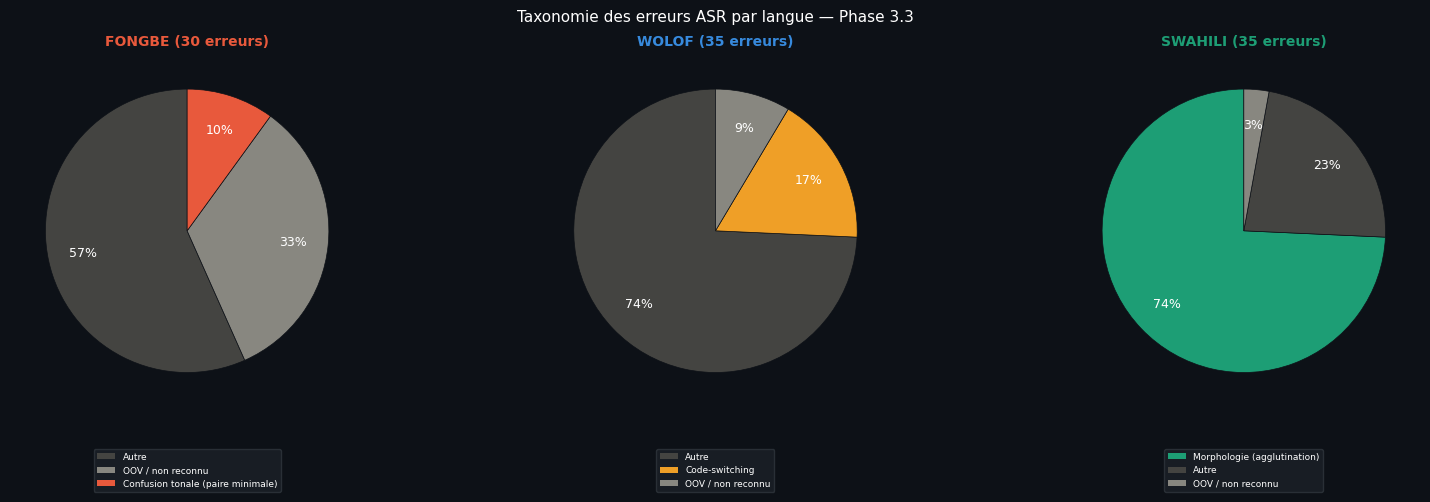

In [12]:
# ── Visualisation de la taxonomie d'erreurs ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Taxonomie des erreurs ASR par langue — Phase 3.3',
             color='white', fontsize=11)

coul_cat = {
    'Confusion tonale (paire minimale)': '#E8593C',
    'Confusion tonale (probable)':       '#D85A30',
    'OOV / non reconnu':                 '#888780',
    'Code-switching':                    '#EF9F27',
    'Morphologie (agglutination)':        '#1D9E75',
    'Autre':                             '#444441',
}

for ax, langue in zip(axes, LANGUES):
    sub = df_err[df_err['langue'] == langue]
    if sub.empty:
        ax.text(0.5, 0.5, 'Aucune erreur', transform=ax.transAxes,
                ha='center', va='center', color='white')
        continue
    counts = sub['categorie'].value_counts()
    couleurs_pie = [coul_cat.get(c, '#444441') for c in counts.index]
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=None,
        autopct='%1.0f%%',
        colors=couleurs_pie,
        startangle=90,
        pctdistance=0.75,
        wedgeprops={'linewidth': 0.5, 'edgecolor': DARK_BG}
    )
    for t in autotexts:
        t.set_color('white')
        t.set_fontsize(9)
    ax.set_title(f'{langue.upper()} ({len(sub)} erreurs)',
                  color=COULEURS[langue], fontsize=10, fontweight='bold')

    # Légende
    patches = [mpatches.Patch(facecolor=coul_cat.get(c,'#444441'), label=c)
               for c in counts.index]
    ax.legend(handles=patches, loc='lower center', fontsize=6.5,
              facecolor='#1C2128', edgecolor=GRID_COL,
              labelcolor='white', bbox_to_anchor=(0.5, -0.25))

plt.tight_layout()
sauver(fig, 'taxonomie_erreurs.png')
plt.show()

## 3.3 Test paires minimales tonales fongbé

In [14]:
# ── Test paires minimales ─────────────────────────────────────────────────────
paires_min = df_meta[df_meta['paire_minimale'] == 'oui']

print('═' * 70)
print('  TEST PAIRES MINIMALES TONALES — le modèle distingue-t-il H vs B ?')
print('═' * 70)

resultats_paires = []

for pid, grp in paires_min.groupby('id_paire'):
    if len(grp) != 2:
        continue
    grp = grp.sort_values('ton_patron',
                           key=lambda x: x.map({'H':0,'B':1}).fillna(2))
    row_h = grp.iloc[0]
    row_b = grp.iloc[1]

    print(f'\n── Paire : {pid}')

    ligne = {
        'id_paire':  pid,
        'ortho_h':   row_h.get('transcription_ortho', ''),
        'ortho_b':   row_b.get('transcription_ortho', ''),
        'trad_h':    row_h.get('traduction_fr', ''),
        'trad_b':    row_b.get('traduction_fr', ''),
    }

    for nom_mod, res_mod in MODELES.items():
        hyp_h = res_mod.get(row_h['id'], {}).get('transcription', '?')
        hyp_b = res_mod.get(row_b['id'], {}).get('transcription', '?')
        hyp_h_n = normaliser(hyp_h)
        hyp_b_n = normaliser(hyp_b)
        distingue = hyp_h_n != hyp_b_n
        statut = ' DISTINGUE' if distingue else ' CONFOND'

        print(f'  [{nom_mod}]  {statut}')
        print(f'    Ton H ({row_h.get("transcription_ortho","?")}): ref="{normaliser(str(row_h.get("transcription_ortho","")))}"'
              f'  → prédit="{hyp_h_n[:50]}"')
        print(f'    Ton B ({row_b.get("transcription_ortho","?")}): ref="{normaliser(str(row_b.get("transcription_ortho","")))}"'
              f'  → prédit="{hyp_b_n[:50]}"')

        ligne[f'{nom_mod}_hyp_h']     = hyp_h
        ligne[f'{nom_mod}_hyp_b']     = hyp_b
        ligne[f'{nom_mod}_distingue'] = distingue

    resultats_paires.append(ligne)

df_paires = pd.DataFrame(resultats_paires)

# Tableau récapitulatif : combien de paires sont distinguées par modèle ?
print('\n' + '═' * 70)
print('  RÉCAPITULATIF — paires distinguées par modèle')
print('═' * 70)
for nom_mod in MODELES:
    col = f'{nom_mod}_distingue'
    if col in df_paires.columns:
        nb  = df_paires[col].sum()
        tot = len(df_paires)
        pct = nb/tot*100 if tot > 0 else 0
        print(f'  {nom_mod:<22} : {nb}/{tot} paires distinguées ({pct:.0f}%)')

df_paires.to_csv(DOSSIER_RES / 'test_paires_minimales.csv',
                  index=False, encoding='utf-8-sig')
print('\n Résultats → resultats_phase3/test_paires_minimales.csv')

══════════════════════════════════════════════════════════════════════
  TEST PAIRES MINIMALES TONALES — le modèle distingue-t-il H vs B ?
══════════════════════════════════════════════════════════════════════

── Paire : pair_faudio_009
  [whisper-small]   CONFOND
    Ton H ( Nán): ref="nán"  → prédit="no"
    Ton B ( Ná): ref="ná"  → prédit="no"
  [whisper-large-v3]   DISTINGUE
    Ton H ( Nán): ref="nán"  → prédit="на"
    Ton B ( Ná): ref="ná"  → prédit="न"

── Paire : pair_faudio_011
  [whisper-small]   DISTINGUE
    Ton H ( Àzɔ́n): ref="àzɔ́n"  → prédit="sorry"
    Ton B ( Àzɔ̌): ref="àzɔ̌"  → prédit="as so"
  [whisper-large-v3]   DISTINGUE
    Ton H ( Àzɔ́n): ref="àzɔ́n"  → prédit="as one"
    Ton B ( Àzɔ̌): ref="àzɔ̌"  → prédit="alzo"

── Paire : pair_faudio_012
  [whisper-small]   DISTINGUE
    Ton H ( Asɔ́): ref="asɔ́"  → prédit="i assume"
    Ton B ( Àsɔ̀): ref="àsɔ̀"  → prédit="as you"
  [whisper-large-v3]   DISTINGUE
    Ton H ( Asɔ́): ref="asɔ́"  → prédit="à sous"
    Ton

  Figure -> figures_phase3/paires_minimales_resultats.png


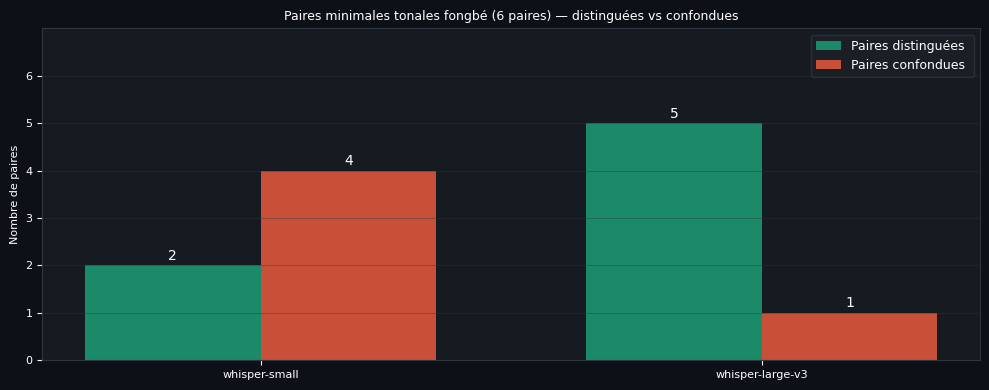

In [15]:
# ── Visualisation paires minimales ────────────────────────────────────────────
if len(df_paires) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(DARK_BG)

    noms_mod = list(MODELES.keys())
    x  = np.arange(len(noms_mod))
    w  = 0.35
    tot = len(df_paires)

    distingues = []
    confondus  = []
    for nom in noms_mod:
        col = f'{nom}_distingue'
        if col in df_paires.columns:
            d = int(df_paires[col].sum())
            distingues.append(d)
            confondus.append(tot - d)
        else:
            distingues.append(0)
            confondus.append(tot)

    b1 = ax.bar(x - w/2, distingues, w, label='Paires distinguées ',
                color='#1D9E75', alpha=0.85)
    b2 = ax.bar(x + w/2, confondus,  w, label='Paires confondues ',
                color='#E8593C', alpha=0.85)

    for bar in list(b1) + list(b2):
        v = int(bar.get_height())
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(v), ha='center', va='bottom', color='white', fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(noms_mod, color='white', fontsize=9)
    ax.set_ylim(0, tot + 1)
    ax.set_yticks(range(tot + 1))
    ax.legend(facecolor='#1C2128', edgecolor=GRID_COL,
              labelcolor='white', fontsize=9)
    style_ax(ax,
             title=f'Paires minimales tonales fongbé ({tot} paires) — distinguées vs confondues',
             ylabel='Nombre de paires')

    plt.tight_layout()
    sauver(fig, 'paires_minimales_resultats.png')
    plt.show()

## 3.4 Synthèse Phase 3

In [16]:
print('═' * 70)
print('  SYNTHÈSE PHASE 3')
print('═' * 70)

print('\n3.2 — Tableau croisé WER (%) :')
print(pivot_wer.to_string())

print('\n3.2 — Tableau croisé CER (%) :')
print(pivot_cer.to_string())

print('\n3.3 — Erreurs par catégorie :')
print(df_err.groupby(['langue','categorie'])['id'].count()
      .rename('nb').to_string())

print('\n3.4 — Paires minimales :')
for nom_mod in MODELES:
    col = f'{nom_mod}_distingue'
    if col in df_paires.columns:
        nb  = int(df_paires[col].sum())
        tot = len(df_paires)
        print(f'  {nom_mod:<22} : {nb}/{tot} paires distinguées')

print('\nFigures générées :')
for f in sorted(DOSSIER_FIG.glob('*.png')):
    print(f'  {f.name}')

print('\n' + '═' * 70)

══════════════════════════════════════════════════════════════════════
  SYNTHÈSE PHASE 3
══════════════════════════════════════════════════════════════════════

3.2 — Tableau croisé WER (%) :
modele   whisper-large-v3  whisper-small
langue                                  
fongbe              115.3          154.1
global               88.1          101.9
swahili              51.5           91.7
wolof               109.0           99.3

3.2 — Tableau croisé CER (%) :
modele   whisper-large-v3  whisper-small
langue                                  
fongbe               81.8          135.6
global               41.3           59.7
swahili              14.3           34.2
wolof                62.4           74.2

3.3 — Erreurs par catégorie :
langue   categorie                        
fongbe   Autre                                17
         Confusion tonale (paire minimale)     3
         OOV / non reconnu                    10
swahili  Autre                                 8
         Morp